#Install and Load

In [1]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load clean data
from google.colab import files
uploaded = files.upload()  # upload walmart_clean.csv

Saving walmart_clean.csv to walmart_clean.csv


In [4]:
df = pd.read_csv('walmart_clean.csv', parse_dates=['Date'])
print("Shape:", df.shape)
df.head()

Shape: (420212, 21)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0


#Feature Engineering

In [5]:
# Encode store type
le = LabelEncoder()
df['Type_Encoded'] = le.fit_transform(df['Type'])

# Select features
features = [
    'Store', 'Dept', 'Year', 'Month', 'Week', 'Quarter',
    'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI',
    'Unemployment', 'Size', 'Type_Encoded', 'Total_MarkDown'
]

# Convert IsHoliday to int
df['IsHoliday'] = df['IsHoliday'].astype(int)

X = df[features]
y = df['Weekly_Sales']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", features)

X shape: (420212, 14)
y shape: (420212,)

Features: ['Store', 'Dept', 'Year', 'Month', 'Week', 'Quarter', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Type_Encoded', 'Total_MarkDown']


#Train/Test Split (80/20 on all 4 lakh rows)

In [6]:
# Time-based split — don't use random split for time series
split_date = '2012-06-01'

train_mask = df['Date'] < split_date
test_mask  = df['Date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (355349, 14)
Test size:  (64863, 14)


#Train XGBoost Model

In [13]:
# Log transform smooths out extreme values
y_train_log = np.log1p(y_train)

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    X_train, y_train_log,
    eval_set=[(X_test, np.log1p(y_test))],
    verbose=100
)

[0]	validation_0-rmse:2.02761
[100]	validation_0-rmse:0.88259
[200]	validation_0-rmse:0.72305
[300]	validation_0-rmse:0.65893
[400]	validation_0-rmse:0.61105
[499]	validation_0-rmse:0.58970


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

#Evaluate

In [14]:
# Predict and reverse log transform
y_pred_log = model_xgb.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Evaluate on filtered set
mask = y_test > 100
y_test_filtered = y_test[mask]
y_pred_filtered = y_pred[mask]

mae  = mean_absolute_error(y_test_filtered, y_pred_filtered)
rmse = np.sqrt(mean_squared_error(y_test_filtered, y_pred_filtered))
mape = np.mean(np.abs((y_test_filtered - y_pred_filtered) / y_test_filtered)) * 100

print(f"\nMAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


MAE:  3,178.85
RMSE: 6,015.83
MAPE: 28.63%


#Feature Importance Plot

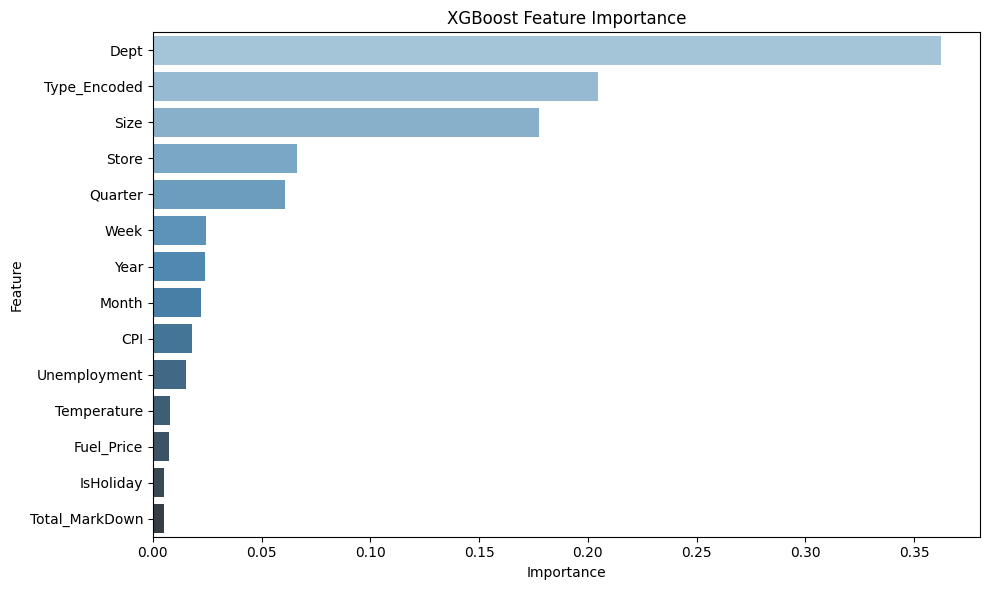


Top 5 Features:
         Feature  Importance
1           Dept    0.362118
12  Type_Encoded    0.204538
11          Size    0.177546
0          Store    0.066065
5        Quarter    0.060559


In [15]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='Blues_d')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 Features:")
print(importance.head())

In [16]:
import joblib

# Save model
joblib.dump(model_xgb, 'xgboost_model.pkl')
print("XGBoost model saved!")

XGBoost model saved!


#Actual Vs Predicted

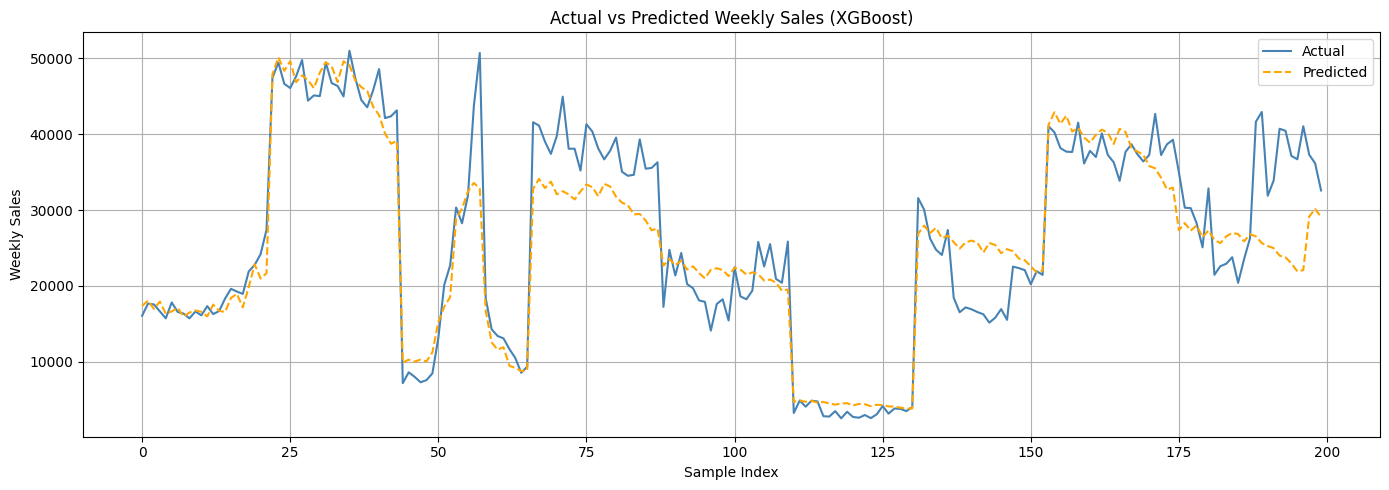

In [17]:
# Sample 200 points for clean visualization
sample = pd.DataFrame({
    'Actual': y_test_filtered.values[:200],
    'Predicted': y_pred_filtered[:200]
}).reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(sample['Actual'], label='Actual', color='steelblue')
plt.plot(sample['Predicted'], label='Predicted', color='orange', linestyle='--')
plt.title('Actual vs Predicted Weekly Sales (XGBoost)')
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('xgb_actual_vs_predicted.png', dpi=150)
plt.show()